<a href="https://colab.research.google.com/github/amyahespanol/Amyah-Espanol-Statistical-Theory-APM1111/blob/main/Stats_FA13_Espanol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

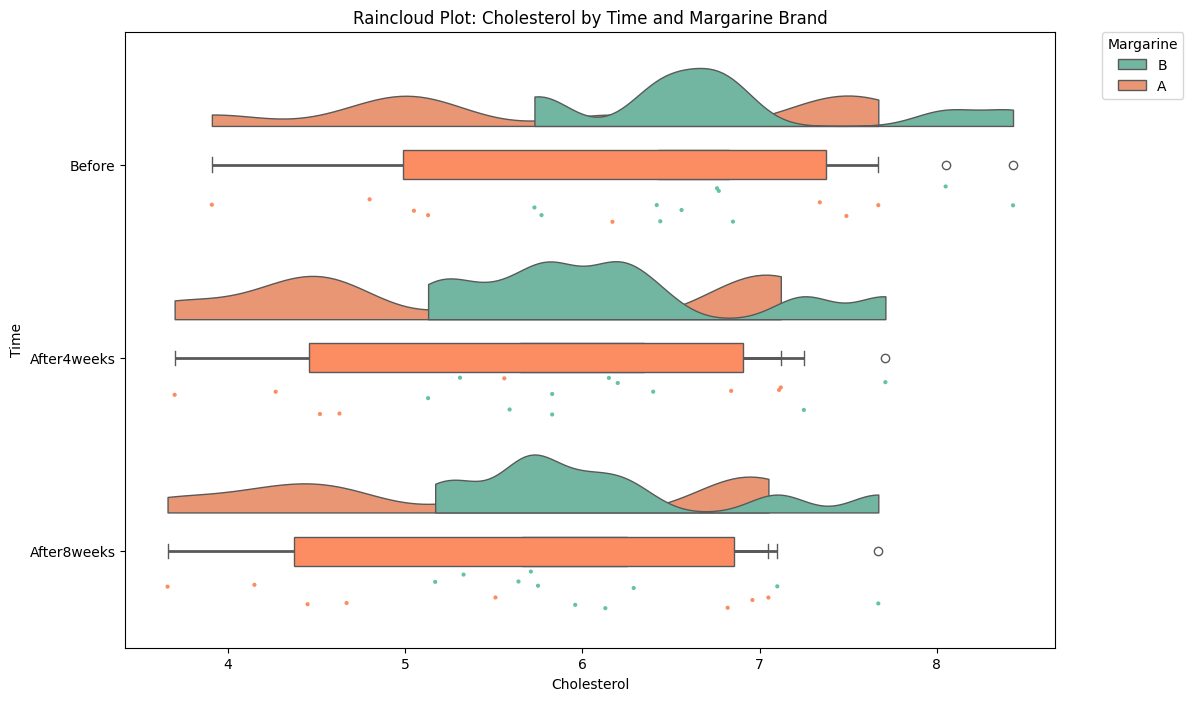



--- Descriptive Statistics and Normality by Margarine B ---
Time                     After4weeks  After8weeks  Before
Valid                         10.000       10.000  10.000
Mean                           6.140        6.075   6.778
Std. Deviation                 0.815        0.779   0.866
Skewness                       0.881        1.124   0.917
Std. Error of Skewness         0.775        0.775   0.775
Kurtosis                       0.233        0.775   0.437
Std. Error of Kurtosis         1.549        1.549   1.549
Shapiro-Wilk                   0.925        0.899   0.881
P-value of Shapiro-Wilk        0.400        0.216   0.134


--- Descriptive Statistics and Normality by Margarine A ---
Time                     After4weeks  After8weeks  Before
Valid                          8.000        8.000   8.000
Mean                           5.469        5.409   5.945
Std. Deviation                 1.388        1.374   1.428
Skewness                       0.200        0.172   0.024
Std. E

In [28]:
!pip install pingouin statsmodels ptitprince -q

import pandas as pd
import numpy as np
import pingouin as pg
from scipy.stats import skew, kurtosis, shapiro, levene
import matplotlib.pyplot as plt
import ptitprince as pt

#Load data
df = pd.read_csv('Cholesterol_R2.csv')
df_long = df.melt(id_vars=['ID', 'Margarine'],
                  value_vars=['Before', 'After4weeks', 'After8weeks'],
                  var_name='Time', value_name='Cholesterol')

#raincloud plot for outliers
plt.figure(figsize=(12, 8))
ax = pt.RainCloud(x='Time', y='Cholesterol', hue='Margarine', data=df_long,
                  palette='Set2', bw=0.2, width_viol=0.6,
                  orient='h', move=0.2)

plt.title('Raincloud Plot: Cholesterol by Time and Margarine Brand')
plt.show()
print("\n" + "="*50 + "\n")

# define the table function
def get_detailed_stats(data):
    stats = {}
    stats['Valid'] = len(data)
    stats['Mean'] = np.mean(data)
    stats['Std. Deviation'] = np.std(data, ddof=1)
    stats['Skewness'] = skew(data, bias=False)
    stats['Std. Error of Skewness'] = np.sqrt(6 / len(data))
    stats['Kurtosis'] = kurtosis(data, bias=False)
    stats['Std. Error of Kurtosis'] = np.sqrt(24 / len(data))
    #shapiro-wilk test
    w_stat, p_val = shapiro(data)
    stats['Shapiro-Wilk'] = w_stat
    stats['P-value of Shapiro-Wilk'] = p_val

    return pd.Series(stats)
margarines = df_long['Margarine'].unique()

for m in margarines:
    print(f"--- Descriptive Statistics and Normality by Margarine {m} ---")
    m_data = df_long[df_long['Margarine'] == m]

    # Group by Time to check each cell
    table = m_data.groupby('Time')['Cholesterol'].apply(get_detailed_stats).unstack(0)

    print(table.round(3))
    print("\n" + "="*50 + "\n")

#Levene's test of homogeneity
print("--- Levene's Test of Homogeneity Variances ---")
results = []
for time in ['Before', 'After4weeks', 'After8weeks']:
    group_a = df_long[(df_long['Time'] == time) & (df_long['Margarine'] == 'A')]['Cholesterol']
    group_b = df_long[(df_long['Time'] == time) & (df_long['Margarine'] == 'B')]['Cholesterol']

    stat, p_val = levene(group_a, group_b)
    results.append({
        'Time': time,
        'Levene Statistic': stat,
        'p-value': p_val
    })
levene_df = pd.DataFrame(results)
print(levene_df.round(3))
print("\n" + "="*50 + "\n")

#Box's M Test
box_m_test = pg.box_m(data=df, dvs=['Before', 'After4weeks', 'After8weeks'], group='Margarine')
print("--- Box's M Test Results ---")
print(box_m_test)
print("\n" + "="*50 + "\n")

# Mauchly's Test of Sphericity
sphericity_test = pg.sphericity(data=df_long, dv='Cholesterol',
                                subject='ID', within='Time')

print("--- Mauchly's Test of Sphericity ---")
print(sphericity_test)
print("\n" + "="*50 + "\n")

#Mixed ANOVA Table
anova_table = pg.mixed_anova(data=df_long, dv='Cholesterol',
                             within='Time', between='Margarine', subject='ID')

print("--- Two-Way Mixed ANOVA Results ---")
print(anova_table.round(4))
print("\n" + "="*50 + "\n")

#Effect of Time within Brand
print("--- Simple Main Effect: Time within Brand ---")
for brand in ['A', 'B']:
    res = pg.rm_anova(data=df_long[df_long['Margarine'] == brand],
                      dv='Cholesterol', within='Time', subject='ID')
    print(f"Margarine {brand}: F({res.at[0,'ddof1']}, {res.at[0,'ddof2']}) = {res.at[0,'F']:.2f}, p = {res.at[0,'p_unc']:.3f}")

print("\n" + "="*50 + "\n")

#Effect of Brand within each Time Point
print("--- Simple Main Effect: Brand within Time ---")
sme_brand = pg.pairwise_tests(data=df_long, dv='Cholesterol', within='Time',
                               between='Margarine', subject='ID')
sme_brand_clean = sme_brand[sme_brand['Contrast'] == 'Time * Margarine'][['Time', 'A', 'B', 'T', 'dof', 'p_unc']]
print(sme_brand_clean.round(3))

print("\n" + "="*50 + "\n")

print("--- Post-Hoc Comparisons (Time) ---")
posthoc = pg.pairwise_tests(data=df_long, dv='Cholesterol', within='Time',
                             subject='ID', padjust='bonf')
print(posthoc[['A', 'B', 'T', 'p_corr', 'hedges']].round(3))